成功加载数据，长度: 2


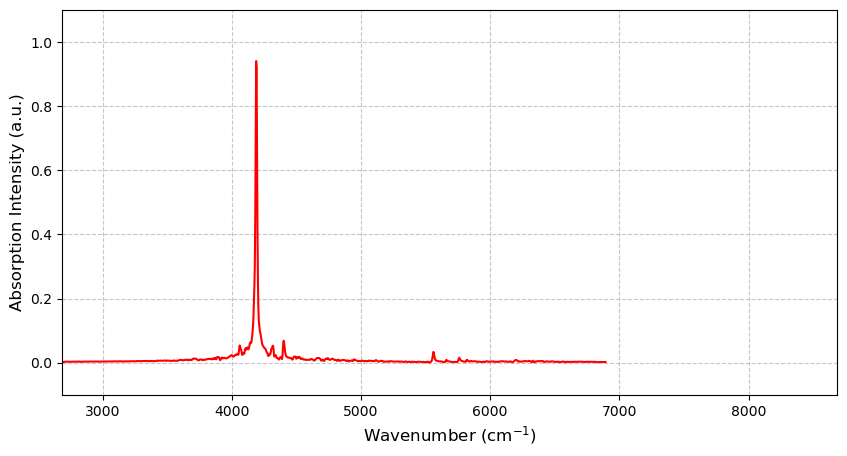

成功加载数据，长度: 2


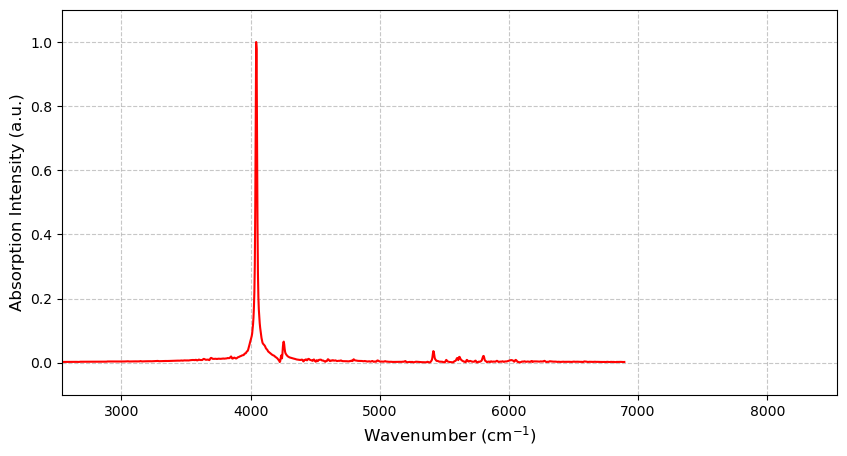

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from renormalizer.utils import constant
# ================= 配置参数 (需与 run_monomer.py 一致) =================
           
# ======================================================================
def autocorr_to_spectrum(path="../singleset/pbi_hexmer_zt.npz",t_gaussian_fs = 2000, offset_ev = 2.13 ):
    try:
        data = np.load(path)
        print(f"成功加载数据，长度: {len(data)}")
    except:
        print("错误：未找到 autocorr_data.npy 文件！")
        return

    times_au = data["time_series"]
    dt_au = times_au[1] - times_au[0]

    autocorr = np.asarray(data["autocorr"])
    t_axis = np.arange(len(autocorr)) * dt_au
    
    t_gaussian_au = t_gaussian_fs * constant.fs2au
    broadening_filter = np.exp(-(t_axis / t_gaussian_au)**2)
    c_t_broadened = autocorr * broadening_filter

    # freq: 1/au (Hartree)
    spectrum = np.fft.fft(c_t_broadened)
    freqs_hartree = - np.fft.fftfreq(len(autocorr), d=dt_au) * 2 * np.pi
    
    # Offset (eV)
    freqs_cm = freqs_hartree * constant.au2cm
    
    intensities = np.abs(spectrum)/np.max(spectrum)

    # 数据筛选 (只取正频率附近的结果)
    # 排序以方便画图
    idx = np.argsort(freqs_cm)
    x = freqs_cm[idx]
    y = intensities[idx]

    plt.figure(figsize=(10, 5))

    peak_pos = x[np.argmax(y)]
    plt.xlim(peak_pos - 1500, peak_pos + 4500)
    plt.ylim(-0.1,1.1)
    plt.plot(x, y, color='red', linewidth=1.5)

    plt.xlabel("Wavenumber (cm$^{-1}$)", fontsize=12)
    plt.ylabel("Absorption Intensity (a.u.)", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # 保存结果
    # plt.savefig(f"monomer_spectrum.png", dpi=300)
    plt.show()

if __name__ == "__main__":
    autocorr_to_spectrum(path="../singleset/pbi_hexmer_zt_chi2.npz")
    autocorr_to_spectrum(path="../multiset/pbi_hexmer_zt_chi1.npz")
    # "../multiset/pbi_dimer.npz"